In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'				    resnet50_model.h5
 Plant_leaf_diseases_dataset_without_augmentation   resnet50_model.keras


In [ ]:
data_dir=('/content/drive/MyDrive/Plant_leaf_diseases_dataset_without_augmentation/Plant_leave_diseases_dataset_without_augmentation')

In [ ]:
data_dir

'/content/drive/MyDrive/Plant_leaf_diseases_dataset_without_augmentation/Plant_leave_diseases_dataset_without_augmentation'

In [ ]:
#

if os.path.exists(data_dir):
    print("Connected successfully Dataset found")
else:
    print("Path not found check your folder name again")


Connected successfully Dataset found


1.Data Exploration


In [ ]:
classes=os.listdir(data_dir)
classes


['Tomato___Leaf_Mold',
 'Tomato___Target_Spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Late_blight',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Septoria_leaf_spot',
 'Tomato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Squash___Powdery_mildew',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Soybean___healthy',
 'Strawberry___healthy',
 'Strawberry___Leaf_scorch',
 'Pepper,_bell___Bacterial_spot',
 'Potato___healthy',
 'Pepper,_bell___healthy',
 'Raspberry___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Grape___Esca_(Black_Measles)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Corn___healthy',
 'Corn___Common_rust',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Corn___Northern_Leaf_Blight',
 'Grape___Black_rot',
 'Apple___Apple_scab',
 'Apple___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Background_without_leaves',
 'Apple___Black_rot',
 

In [ ]:
Total_classes=len(classes)
print('total number of class in the dataset are:',Total_classes)

total number of class in the dataset are: 39


In [ ]:
unique_classes=[]         #to see how many different types of plant are present in the dataset
for i in classes:
  plants_name=i.split('___')[0]
  unique_classes.append(plants_name)

unique_plants=set(unique_classes) #set will remove duplicates
unique_plants.remove('Background_without_leaves')
print('total numbers of unique plants:',len(unique_plants))
unique_plants


total numbers of unique plants: 14


{'Apple',
 'Blueberry',
 'Cherry',
 'Corn',
 'Grape',
 'Orange',
 'Peach',
 'Pepper,_bell',
 'Potato',
 'Raspberry',
 'Soybean',
 'Squash',
 'Strawberry',
 'Tomato'}

In [ ]:
healthy_classes=[cls for cls in classes if 'healthy' in cls.lower()]
diseased_classes=[cls for cls in classes if 'healthy' not in cls.lower()]

print('Total number of classes:',len(classes))
print('total number of healthy classes:',len(healthy_classes))
print('total number of diseased classes:',len(diseased_classes))

Total number of classes: 39
total number of healthy classes: 12
total number of diseased classes: 27


In [ ]:
for c in healthy_classes: #name of healthy plants
  print(c)

Tomato___healthy
Soybean___healthy
Strawberry___healthy
Potato___healthy
Pepper,_bell___healthy
Raspberry___healthy
Peach___healthy
Corn___healthy
Grape___healthy
Apple___healthy
Cherry___healthy
Blueberry___healthy


In [ ]:
for c in diseased_classes:  #name of diseased plants
  print(c)

Tomato___Leaf_Mold
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Late_blight
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Septoria_leaf_spot
Tomato___Bacterial_spot
Tomato___Early_blight
Squash___Powdery_mildew
Potato___Early_blight
Potato___Late_blight
Strawberry___Leaf_scorch
Pepper,_bell___Bacterial_spot
Orange___Haunglongbing_(Citrus_greening)
Grape___Esca_(Black_Measles)
Peach___Bacterial_spot
Corn___Common_rust
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Corn___Northern_Leaf_Blight
Grape___Black_rot
Apple___Apple_scab
Cherry___Powdery_mildew
Background_without_leaves
Apple___Black_rot
Apple___Cedar_apple_rust
Corn___Cercospora_leaf_spot Gray_leaf_spot


In [ ]:
image_counts = {}   #for numbers of image in each class

for c in classes:
    cls_path = os.path.join(data_dir, c)
    image_counts[c] = len(os.listdir(cls_path))

a=list(image_counts.items())
df=pd.DataFrame(a,columns=['class','Image Count'])
df


,class,Image Count
0,Tomato___Leaf_Mold,952
1,Tomato___Target_Spot,1404
2,Tomato___Tomato_mosaic_virus,373
3,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
4,Tomato___Late_blight,1909
5,Tomato___Spider_mites Two-spotted_spider_mite,1676
6,Tomato___Septoria_leaf_spot,1771
7,Tomato___healthy,1591
8,Tomato___Bacterial_spot,2127
9,Tomato___Early_blight,1000


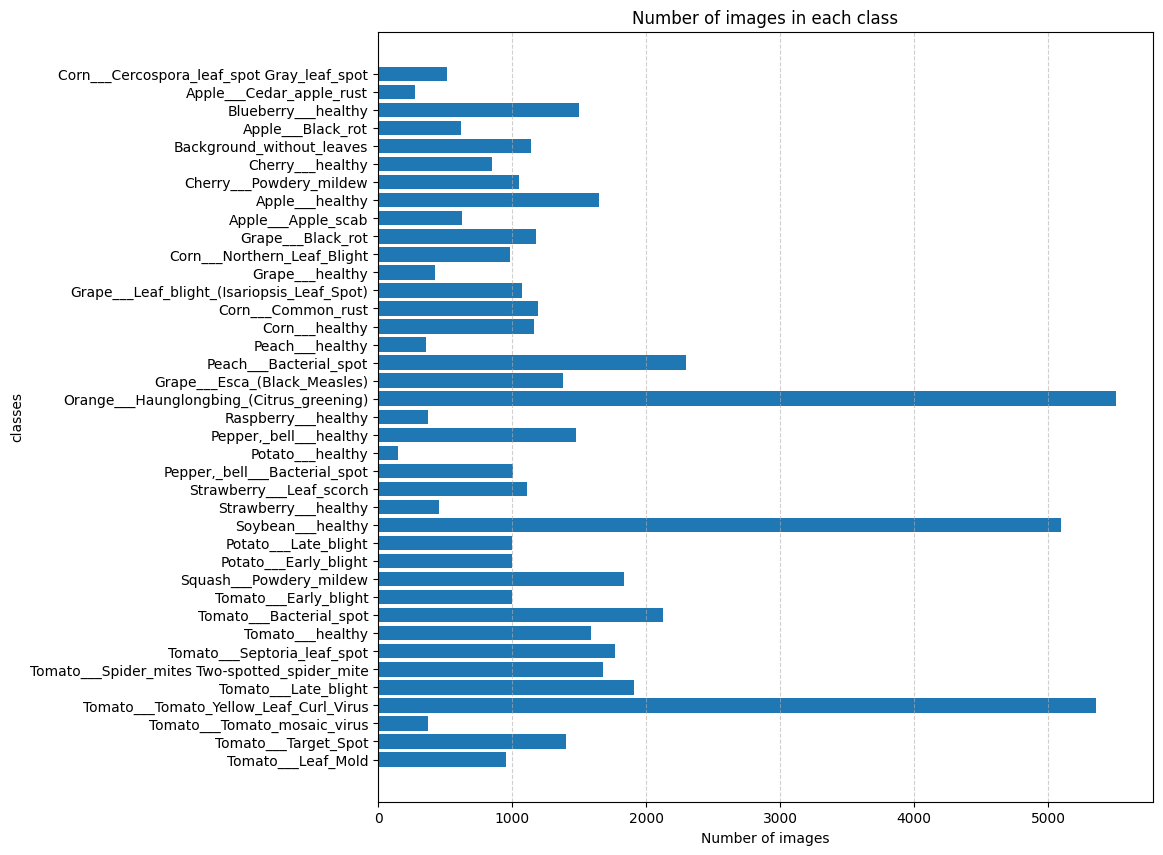

In [ ]:
x=[x[0] for x in a]
y=[x[1] for x in a]

plt.figure(figsize=(10,10))
plt.barh(x,y)
plt.title('Number of images in each class')
plt.xlabel('Number of images')
plt.ylabel('classes')
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.show()

2. Data preprocessing


In [ ]:


image_class=classes[0]
image_path=os.path.join(data_dir,image_class) #directory setup
fstimg_path=os.path.join(image_path,os.listdir(image_path)[0])

img=image.load_img(fstimg_path) #PIL
img_array=image.img_to_array(img) #Numpy array




In [ ]:
img_array.shape #image is RGB

(256, 256, 3)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

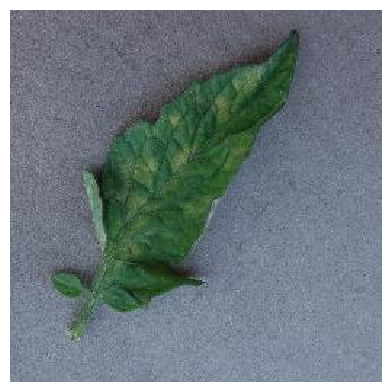

In [ ]:
plt.matshow(img)
plt.axis('off')

In [ ]:
data=ImageDataGenerator(
    rescale=1./255,  #normalized to 0-1
    validation_split=0.2  #20% for validation
)

In [ ]:
Train_data=data.flow_from_directory(
    directory=data_dir,
    batch_size=32,
    target_size=(256,256),
    shuffle=True,
    class_mode='categorical',
    subset='training'

)

validation_data=data.flow_from_directory(
    directory=data_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'

)

Found 44381 images belonging to 39 classes.
Found 11078 images belonging to 39 classes.


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

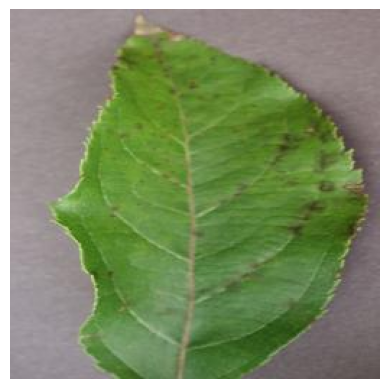

In [ ]:
x_batch,y_batch=next(validation_data)

plt.imshow(x_batch[0])
plt.axis('off')

Resnet50

In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
pmodel=ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
for layer in pmodel.layers:
    layer.trainable = False


In [ ]:
x=pmodel.output
x=GlobalAveragePooling2D()(x)
x=Dense(512,activation='relu')(x)
x=Dense(39,activation='softmax')(x)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
fmodel=Model(inputs=pmodel.input,outputs=x)

In [ ]:
fmodel.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = fmodel.fit(
    Train_data,
    validation_data=validation_data,
    epochs=5
)


Epoch 1/5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 445s 321ms/step - accuracy: 0.2613 - loss: 2.8594 - val_accuracy: 0.2906 - val_loss: 2.6573
Epoch 2/5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 238s 172ms/step - accuracy: 0.3039 - loss: 2.6154 - val_accuracy: 0.3279 - val_loss: 2.4776
Epoch 3/5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 235s 169ms/step - accuracy: 0.3476 - loss: 2.4388 - val_accuracy: 0.3532 - val_loss: 2.3464
Epoch 4/5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 231s 166ms/step - accuracy: 0.3752 - loss: 2.3096 - val_accuracy: 0.3863 - val_loss: 2.2227
Epoch 5/5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 239s 173ms/step - accuracy: 0.4026 - loss: 2.1904 - val_accuracy: 0.4083 - val_loss: 2.1291


In [ ]:
fmodel.save('/content/drive/MyDrive/resnet50_model.keras')


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'				    resnet50_model.h5
 Plant_leaf_diseases_dataset_without_augmentation   resnet50_model.keras


VGG16


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [ ]:
vggTrain_data=data.flow_from_directory(
    directory=data_dir,
    batch_size=32,
    target_size=(224,224),
    shuffle=True,
    class_mode='categorical',
    subset='training'

)


vggvalidation_data=data.flow_from_directory(
    directory=data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'

)

Found 44381 images belonging to 39 classes.
Found 11078 images belonging to 39 classes.


In [ ]:
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
final_vgg_model = Sequential([
    vgg_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(39, activation='softmax')
])

In [ ]:
final_vgg_model .compile(
     optimizer=Adam(learning_rate=0.0001),
     loss='categorical_crossentropy',
     metrics=['accuracy']
)

In [ ]:
Train_VGG = final_vgg_model.fit(
    vggTrain_data,
    validation_data=vggvalidation_data,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
 237/1387 ━━━━━━━━━━━━━━━━━━━━ 7:29:22 23s/step - accuracy: 0.3596 - loss: 2.6162